## Setup Koneksi & Environmetn

In [ ]:
import pandas as pd
import numpy as np

from supabase import create_client, Client
from pathlib import Path
import os
from dotenv import load_dotenv

# Dapatkan lokasi folder saat notebook ini berjalan
_notebook_dir = Path.cwd()

# Menyesuaikan path .env berdasarkan posisi notebook
if _notebook_dir.name == "notebooks":
    env_path = _notebook_dir.parent / ".env"
else:
    env_path = _notebook_dir / "backend" / ".env"

load_dotenv(env_path)

# Inisialisasi Supabase Client
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    print("Error: Kredensial Supabase tidak ditemukan di file .env")
else:
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
    print("Koneksi Supabase berhasil diinisiasi!")

Koneksi Supabase berhasil diinisiasi!


## Load All Data

In [10]:
def fetch_all(table, columns="*", page=1000):
    """Supabase membatasi 1000 baris/request, jadi diambil per halaman."""
    rows, start = [], 0
    while True:
        res = (supabase.table(table).select(columns)
               .order("recorded_date").order("card_id")
               .range(start, start + page - 1).execute())
        rows.extend(res.data)
        if len(res.data) < page:
            break
        start += page
    return pd.DataFrame(rows)

df_all = fetch_all("card_price_history")
df_all["recorded_date"] = pd.to_datetime(df_all["recorded_date"])

PRICE_COLS = [c for c in df_all.columns
              if c.startswith(("tcg_", "cardmarket_")) or c == "effective_market_price"]
df_all[PRICE_COLS] = df_all[PRICE_COLS].apply(pd.to_numeric, errors="coerce")
df_all = df_all.sort_values(["card_id", "recorded_date"]).reset_index(drop=True)

print(f"Baris: {len(df_all):,} | Kartu: {df_all['card_id'].nunique():,}")
print(f"Kolom harga: {PRICE_COLS}")

Baris: 88,964 | Kartu: 20,617
Kolom harga: ['tcg_normal_market', 'tcg_normal_low', 'tcg_normal_mid', 'tcg_normal_high', 'tcg_holo_market', 'tcg_holo_low', 'tcg_holo_mid', 'tcg_holo_high', 'tcg_reverse_market', 'cardmarket_trend', 'cardmarket_avg_sell', 'cardmarket_low', 'cardmarket_avg1', 'cardmarket_avg7', 'cardmarket_avg30', 'effective_market_price']


## Ringkasan Data Per Tanggal

In [11]:
per_day = (df_all.groupby("recorded_date")
           .agg(n_rows=("card_id", "size"), n_cards=("card_id", "nunique")))
print(per_day)
print("\nDuplikat (kartu+tanggal):", df_all.duplicated(["card_id", "recorded_date"]).sum())

               n_rows  n_cards
recorded_date                 
2026-09-22      20197    20197
2026-09-23      17132    17132
2026-09-24      16118    16118
2026-09-25      16867    16867
2026-09-28      18650    18650

Duplikat (kartu+tanggal): 0


## Cek Perubahan Harga

In [12]:
chg = {}
for c in PRICE_COLS:
    diff = df_all.groupby("card_id")[c].diff()
    chg[c] = (diff.dropna() != 0).mean() * 100

print("% perubahan nilai antar tanggal, per kolom:")
print(pd.Series(chg).round(2).sort_values())

print("\nJam penulisan data per tanggal:")
print(df_all.groupby("recorded_date")["created_at"].agg(["min", "max"]))

% perubahan nilai antar tanggal, per kolom:
cardmarket_trend           0.00
cardmarket_avg_sell        0.00
cardmarket_low             0.00
cardmarket_avg1            0.00
cardmarket_avg7            0.00
cardmarket_avg30           0.00
tcg_normal_low             6.40
tcg_reverse_market        19.12
tcg_holo_low              19.60
tcg_holo_high             21.62
tcg_normal_mid            24.87
tcg_normal_market         27.26
effective_market_price    31.93
tcg_normal_high           35.50
tcg_holo_market           43.94
tcg_holo_mid              50.75
dtype: float64

Jam penulisan data per tanggal:
                                            min  \
recorded_date                                     
2026-09-22     2026-09-22T15:39:21.354218+00:00   
2026-09-23     2026-09-23T04:07:56.640254+00:00   
2026-09-24     2026-09-24T04:09:42.493078+00:00   
2026-09-25     2026-09-25T04:23:14.584012+00:00   
2026-09-28     2026-09-28T04:46:51.709505+00:00   

                                      

## Deret harga TCGplayer per kartu

In [14]:
MKT_COLS = ["tcg_holo_market", "tcg_normal_market", "tcg_reverse_market"]

# Per kartu: pilih kolom varian dengan data terbanyak (seri), lalu pakai itu di semua tanggal
cnt = df_all.groupby("card_id")[MKT_COLS].count()
best_col = cnt.idxmax(axis=1)[cnt.max(axis=1) > 0]

df_all["price_usd"] = np.nan
for col in MKT_COLS:
    ids = best_col[best_col == col].index
    m = df_all["card_id"].isin(ids)
    df_all.loc[m, "price_usd"] = df_all.loc[m, col]

print("Kartu dengan deret harga TCGplayer:", df_all.loc[df_all["price_usd"].notna(), "card_id"].nunique())
print("Varian terpilih:\n", best_col.value_counts())

Kartu dengan deret harga TCGplayer: 18689
Varian terpilih:
 tcg_normal_market     11375
tcg_holo_market        7271
tcg_reverse_market       43
Name: count, dtype: int64


## Sinyal BUY/HOLD/SELL

Kartu dinilai: 7,007
signal
HOLD        6083
BUY          490
SELL         433
CEK_DATA       1
Name: count, dtype: int64

Top 10 naik:
           n_days  last_date  first_price  last_price  chg_pct signal
card_id                                                             
ru1-13         5 2026-09-28        52.67       89.98    70.84    BUY
pop4-13        5 2026-09-28       224.82      369.63    64.41    BUY
xyp-XY11       4 2026-09-28         1.99        3.25    63.32    BUY
dp5-61         5 2026-09-28         0.96        1.55    61.46    BUY
smp-SM23       5 2026-09-28         1.86        2.90    55.91    BUY
hgss4-60       4 2026-09-28         6.65       10.36    55.79    BUY
dpp-DP53       4 2026-09-28        93.22      142.50    52.86    BUY
sv9-56         5 2026-09-28         1.70        2.55    50.00    BUY
sv5-81         4 2026-09-28         0.81        1.14    40.74    BUY
bwp-BW19       5 2026-09-28         9.18       12.84    39.87    BUY

Top 10 turun:
                n_da

C:\Users\Tigro\AppData\Local\Temp\ipykernel_24748\4072181466.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print("\nTop 10 naik:\n",  mom[mom.signal == "BUY"].nlargest(10, "chg_pct").round(2))
C:\Users\Tigro\AppData\Local\Temp\ipykernel_24748\4072181466.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print("\nTop 10 turun:\n", mom[mom.signal == "SELL"].nsmallest(10, "chg_pct").round(2))


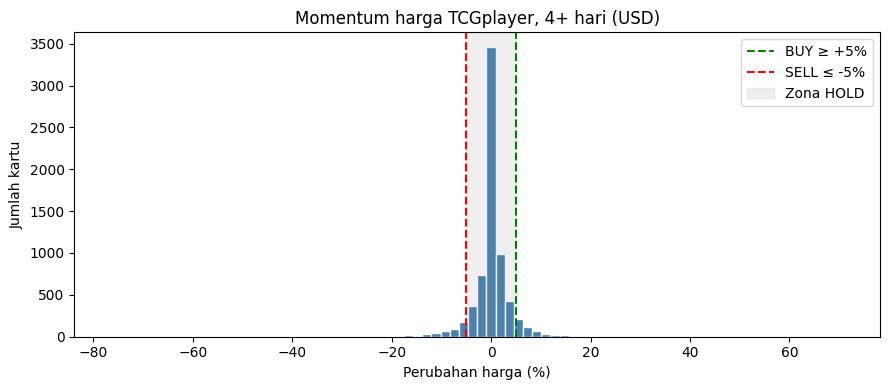

In [19]:
import matplotlib.pyplot as plt   # taruh di Cell 1 kalau mau rapi

HOLD_LOW, HOLD_HIGH = -5.0, 5.0    # zona HOLD (% perubahan sejak titik pertama)
MIN_PRICE     = 1.0                # USD
MIN_DAYS      = 4
OUTLIER_RATIO = 3.0                # perubahan >3× naik atau turun → cek manual

latest = df_all["recorded_date"].max()
g = (df_all.dropna(subset=["price_usd"]).sort_values(["card_id", "recorded_date"])
     .groupby("card_id"))
mom = g.agg(n_days=("recorded_date", "nunique"), last_date=("recorded_date", "last"),
            first_price=("price_usd", "first"), last_price=("price_usd", "last"))

mom = mom[(mom["n_days"] >= MIN_DAYS) & (mom["last_date"] == latest)
          & (mom["first_price"] > 0) & (mom["last_price"] >= MIN_PRICE)].copy()
mom["chg_pct"] = (mom["last_price"] / mom["first_price"] - 1) * 100

mom["signal"] = np.select([mom["chg_pct"] >= HOLD_HIGH, mom["chg_pct"] <= HOLD_LOW],
                          ["BUY", "SELL"], default="HOLD")
bad = np.log(mom["last_price"] / mom["first_price"]).abs() > np.log(OUTLIER_RATIO)
mom.loc[bad, "signal"] = "CEK_DATA"

print(f"Kartu dinilai: {len(mom):,}")
print(mom["signal"].value_counts())
print("\nTop 10 naik:\n",  mom[mom.signal == "BUY"].nlargest(10, "chg_pct").round(2))
print("\nTop 10 turun:\n", mom[mom.signal == "SELL"].nsmallest(10, "chg_pct").round(2))

# ── Histogram (dipotong ±100% agar outlier tidak merusak grafik)
plot_data = mom.loc[mom["chg_pct"].between(-100, 100), "chg_pct"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(plot_data, bins=80, color="steelblue", edgecolor="white")
ax.axvline(HOLD_HIGH, color="green", ls="--", label=f"BUY ≥ {HOLD_HIGH:+.0f}%")
ax.axvline(HOLD_LOW,  color="red",   ls="--", label=f"SELL ≤ {HOLD_LOW:+.0f}%")
ax.axvspan(HOLD_LOW, HOLD_HIGH, color="gray", alpha=0.12, label="Zona HOLD")
ax.set_title(f"Momentum harga TCGplayer, {MIN_DAYS}+ hari (USD)")
ax.set_xlabel("Perubahan harga (%)")
ax.set_ylabel("Jumlah kartu")
ax.legend()
plt.tight_layout()
plt.show()